# Curated MIMIC-III Analysis 


In [1]:
import warnings
from pathlib import Path

from IPython.display import display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')


# Setup

In [2]:
# Runtime configuration
CURATED_ROOT = Path('..') / 'data' / 'curated'
DATAFILE_NAME = 'all_hourly_data.h5'

# Variants to compare against baseline
SCENARIOS = [
    'age35_range5','age35_range10','age35_range15',
    'age45_range5','age45_range10','age45_range15',
    'age55_range5','age55_range10','age55_range15',
    'min48hr','min18age','minperc5',
]

AGG_METHODS = [
    'mean','median','standard deviation','mean deviation','maximum deviation'
]

LABELS = ['icu_los','mortality']
SEEDS = [22,985,439,81]
TEST_SIZE = 0.2

# Use the full cohort (no downsampling)
MAX_RECORDS_PER_SCENARIO = None

MODEL_KWARGS = dict(max_iter=500, solver='liblinear', random_state=0)
FALLBACK_BASELINE_SCENARIO = 'baseline_nofilters'

print('Curated root:', CURATED_ROOT.resolve())
print('Variants:', len(SCENARIOS))


Curated root: /home/ccampb47/work/MIMIC_Extract/data/curated
Variants: 12


In [3]:
def _get_time_level_name(x_index):
    names = list(x_index.names)
    for candidate in ['hours_in','time','hour','Hour']:
        if candidate in names:
            return candidate
    return names[-1]

def _record_id_levels(x_index):
    t = _get_time_level_name(x_index)
    return [n for n in x_index.names if n != t]

def _select_pos_label(patients_df, target_label):
    if target_label == 'icu_los':
        return (patients_df['los_icu'] > 3).astype(int)
    if target_label == 'mortality':
        if 'mort_hosp' in patients_df.columns:
            return patients_df['mort_hosp'].astype(int)
        if 'hospital_expire_flag' in patients_df.columns:
            return patients_df['hospital_expire_flag'].astype(int)
        raise KeyError('No mortality column found in patients_df')
    raise ValueError('Unknown target label')


# Variant loader 

In [4]:
def _pick_datafile(scenario_dir):
    candidates = ['all_hourly_data.h5', 'all_hourly_data_5000.h5', 'all_hourly_data_2000.h5']
    for c in candidates:
        fp = scenario_dir / c
        if fp.exists():
            return fp
    raise FileNotFoundError(f'No all_hourly_data*.h5 found in {scenario_dir}')

def load_curated_scenario(scenario_name, data_root=CURATED_ROOT, load_X=True):
    scenario_dir = data_root / scenario_name
    datafile = _pick_datafile(scenario_dir)

    X = None
    if load_X:
        X = pd.read_hdf(str(datafile), 'vitals_labs')

    patients = pd.read_hdf(str(datafile), 'patients')

    try:
        interventions = pd.read_hdf(str(datafile), 'interventions')
    except Exception:
        interventions = None

    return {
        'name': scenario_name,
        'X': X,
        'patients': patients,
        'interventions': interventions,
        'datafile': datafile,
    }

def maybe_sample_record_ids(patients_df, max_records):
    if max_records is None:
        return patients_df
    if len(patients_df) <= max_records:
        return patients_df
    return patients_df.sample(max_records, random_state=0)

def subset_X_by_patients(X, patients_df):
    """Return only time-series rows whose record-id tuple is in patients_df.

    `vitals_labs` is stored in fixed format so we cannot row-filter on read;
    we subset after read.
    """
    time_level = _get_time_level_name(X.index)
    rec_index = X.index.droplevel(time_level)
    keep = rec_index.isin(patients_df.index)
    return X[keep]

# Mirrors the convention used by Experiment_Statistics.ipynb: the "_fast"
# duplicate of baseline_nofilters must never appear as a variant being
# compared against the actual baseline.
EXCLUDED_EXPERIMENTS = {'baseline_nofilters_fast'}

VARIANT_OBJS = []
for s in SCENARIOS:
    if s in EXCLUDED_EXPERIMENTS:
        continue
    print('Loading patients only:', s)
    obj = load_curated_scenario(s, load_X=False)
    obj['patients'] = maybe_sample_record_ids(obj['patients'], MAX_RECORDS_PER_SCENARIO)
    VARIANT_OBJS.append(obj)

assert all(v['name'] not in EXCLUDED_EXPERIMENTS for v in VARIANT_OBJS)
print('Effective variants:', len(VARIANT_OBJS))
print('Loaded variants:', [v['name'] for v in VARIANT_OBJS])


Loading patients only: age35_range5


Loading patients only: age35_range10


Loading patients only: age35_range15
Loading patients only: age45_range5


Loading patients only: age45_range10


Loading patients only: age45_range15


...

Loading patients only: age55_range15


Loading patients only: min48hr


Loading patients only: min18age


Loading patients only: minperc5


Effective variants: 12
Loaded variants: ['age35_range5', 'age35_range10', 'age35_range15', 'age45_range5', 'age45_range10', 'age45_range15', 'age55_range5', 'age55_range10', 'age55_range15', 'min48hr', 'min18age', 'minperc5']


# Baseline loader 

In [5]:
# Baseline: load from a curated scenario directly (skips DuckDB export)
BASELINE = load_curated_scenario(FALLBACK_BASELINE_SCENARIO, load_X=True)
BASELINE['patients'] = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
print('Baseline:', BASELINE['name'], 'X:', BASELINE['X'].shape, 'patients:', BASELINE['patients'].shape)


Baseline: baseline_nofilters X: (2200954, 21) patients: (34472, 29)


# Lens plots 

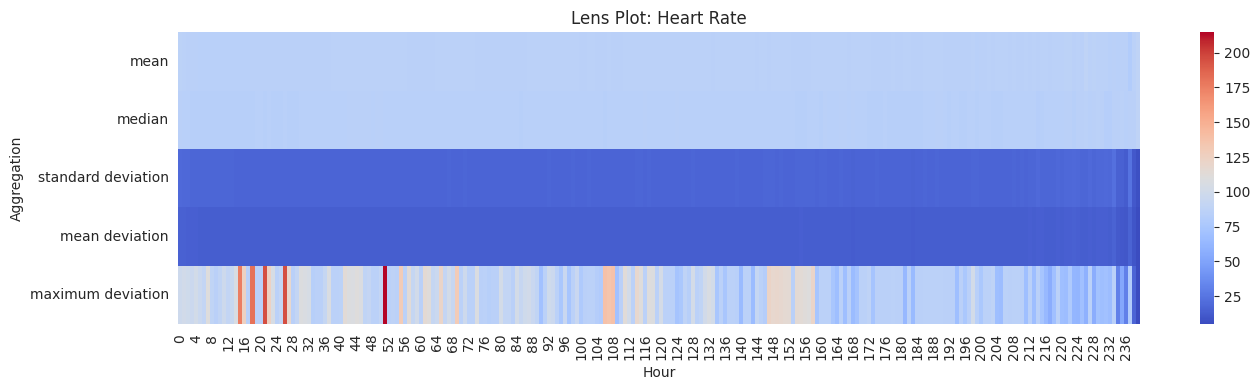

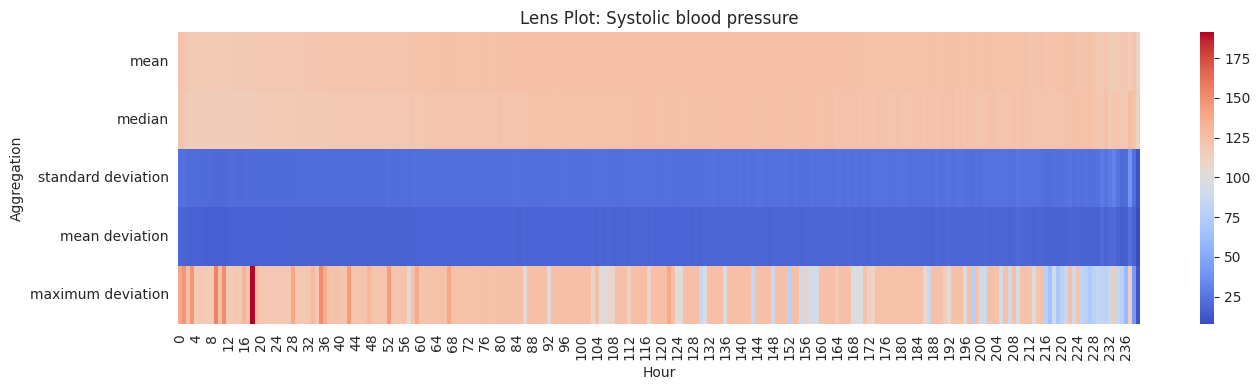

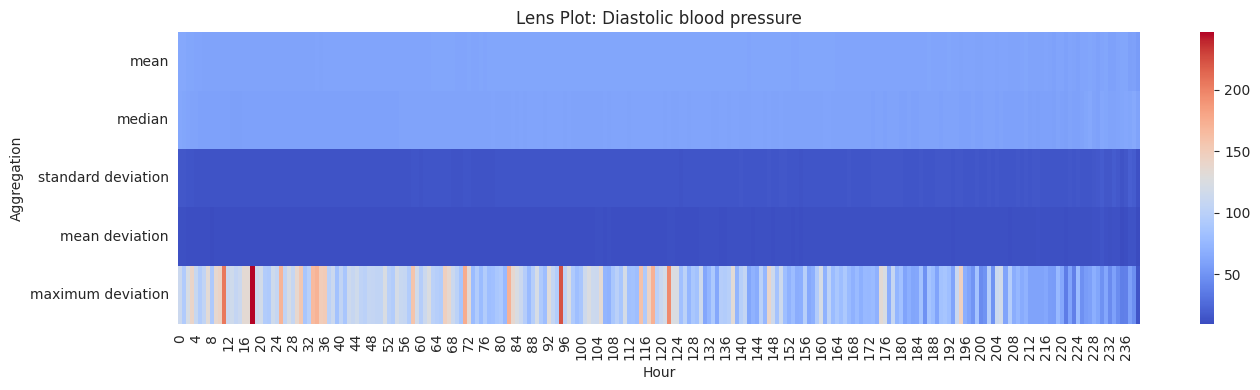

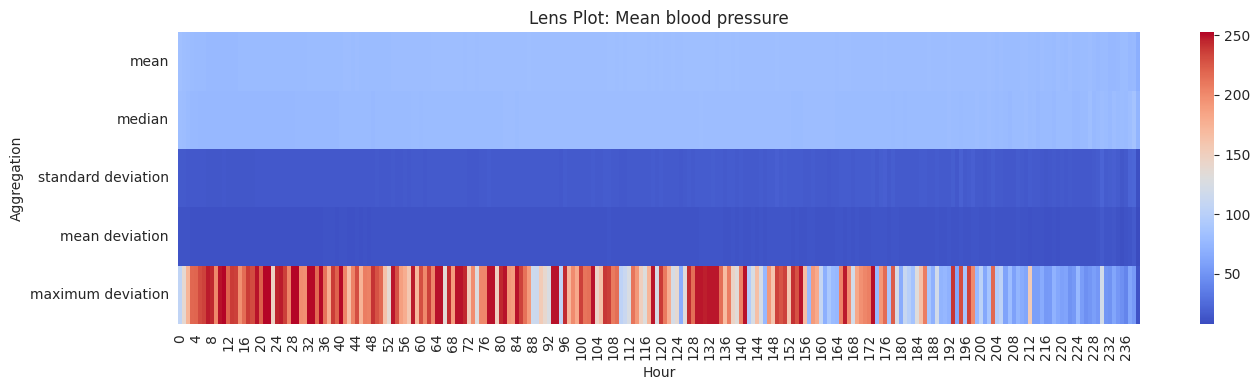

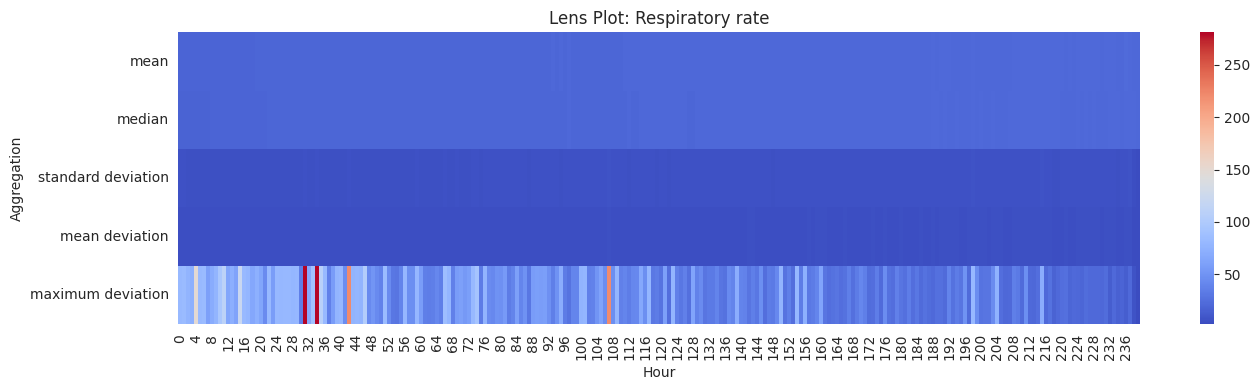

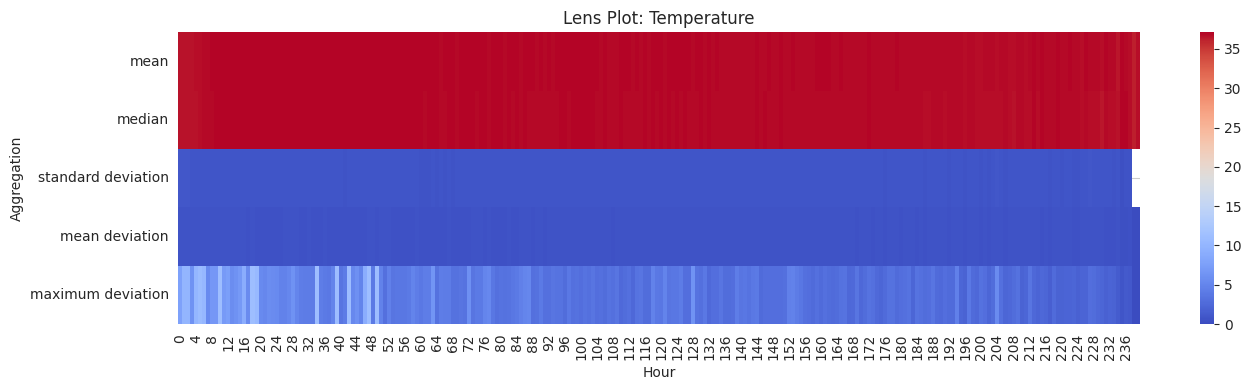

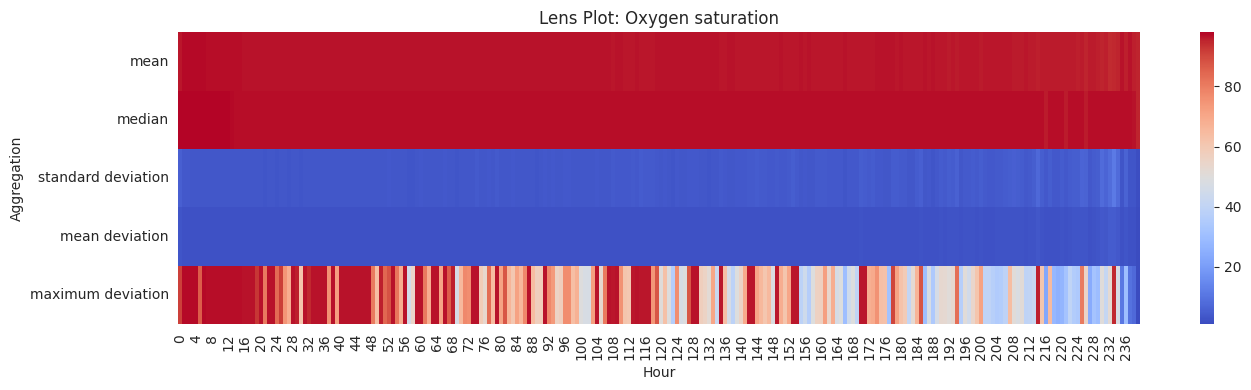

In [6]:
LENS_FEATURES = [
    'Heart Rate',
    'Systolic blood pressure',
    'Diastolic blood pressure',
    'Mean blood pressure',
    'Respiratory rate',
    'Temperature',
    'Oxygen saturation',
]

def _find_feature_name(feature_map, target_name):
    # Prefer exact case-insensitive match first.
    key = target_name.lower()
    if key in feature_map:
        return feature_map[key]

    # Fallback aliases for common naming variations.
    aliases = {
        'Heart Rate': ['heart rate', 'heartrate', 'pulse'],
        'Systolic blood pressure': ['systolic blood pressure', 'sbp'],
        'Diastolic blood pressure': ['diastolic blood pressure', 'dbp'],
        'Mean blood pressure': ['mean blood pressure', 'map'],
        'Respiratory rate': ['respiratory rate', 'resp rate', 'rr'],
        'Temperature': ['temperature', 'temp'],
        'Oxygen saturation': ['oxygen saturation', 'spo2', 'o2 saturation'],
    }.get(target_name, [target_name.lower()])

    for alias in aliases:
        if alias in feature_map:
            return feature_map[alias]
    return None

def _aggregate_series_by_hour(series, hour_values, method):
    s = pd.Series(series.values, index=hour_values)
    if method == 'mean':
        return s.groupby(level=0).mean()
    if method == 'median':
        return s.groupby(level=0).median()
    if method == 'standard deviation':
        return s.groupby(level=0).std(ddof=1)
    if method == 'mean deviation':
        return s.groupby(level=0).apply(lambda x: (x - x.mean()).abs().mean())
    if method == 'maximum deviation':
        return s.groupby(level=0).apply(lambda x: (x - x.mean()).abs().max())
    raise ValueError(f'Unknown method: {method}')

def build_lens_method_hour_matrix(X, requested_feature, requested_methods):
    if not isinstance(X.columns, pd.MultiIndex):
        raise ValueError('Expected MultiIndex columns in vitals_labs data.')

    time_level = _get_time_level_name(X.index)
    hour_values = X.index.get_level_values(time_level)
    all_hours = np.sort(np.asarray(pd.Index(hour_values).unique(), dtype=int))

    mean_cols = [c for c in X.columns if str(c[1]).lower() == 'mean']
    feature_map = {str(c[0]).lower(): str(c[0]) for c in mean_cols}

    actual = _find_feature_name(feature_map, requested_feature)
    if actual is None:
        matrix = pd.DataFrame(np.nan, index=requested_methods, columns=all_hours)
        matrix.columns.name = 'Hour'
        matrix.index.name = 'Aggregation'
        return matrix, True

    col = next(c for c in mean_cols if str(c[0]) == actual)
    rows = []
    for method in requested_methods:
        agg = _aggregate_series_by_hour(X[col], hour_values, method)
        agg = agg.reindex(all_hours)
        rows.append(pd.Series(agg.values, index=all_hours, name=method))

    matrix = pd.DataFrame(rows, index=requested_methods)
    matrix.columns.name = 'Hour'
    matrix.index.name = 'Aggregation'
    return matrix, False


def plot_lens_method_hour_heatmap(matrix, feature, missing):
    plt.figure(figsize=(14, 4))
    sns.heatmap(matrix, cmap='coolwarm')
    title = f'Lens Plot: {feature}'
    if missing:
        title += ' (missing in dataset)'
    plt.title(title)
    plt.xlabel('Hour')
    plt.ylabel('Aggregation')
    plt.tight_layout()
    plt.show()


# Build lens plots from baseline vitals_labs data.
base_pat = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
X_base_small = subset_X_by_patients(BASELINE['X'], base_pat)

for feature in LENS_FEATURES:
    matrix, missing = build_lens_method_hour_matrix(X_base_small, feature, AGG_METHODS)
    plot_lens_method_hour_heatmap(matrix, feature, missing)


# Record-level feature aggregation 

In [7]:
def build_record_aggregated_features(X, method):
    time_level = _get_time_level_name(X.index)
    rec_levels = _record_id_levels(X.index)
    g = X.groupby(level=rec_levels)
    if method == 'mean':
        return g.mean()
    if method == 'median':
        return g.median()
    if method == 'standard deviation':
        return g.std(ddof=1)
    if method == 'mean deviation':
        def _mean_dev(df):
            m = df.mean(axis=0)
            return (df.sub(m, axis=1).abs()).mean(axis=0)
        return g.apply(_mean_dev)
    if method == 'maximum deviation':
        def _max_dev(df):
            m = df.mean(axis=0)
            return (df.sub(m, axis=1).abs()).max(axis=0)
        return g.apply(_max_dev)
    raise ValueError(f'Unknown method: {method}')


# McNemar evaluation + significance 

Evaluating variant=age35_range5 target=icu_los method=mean


Evaluating variant=age35_range10 target=icu_los method=mean


Evaluating variant=age35_range15 target=icu_los method=mean


Evaluating variant=age45_range5 target=icu_los method=mean


Evaluating variant=age45_range10 target=icu_los method=mean


...

Evaluating variant=min48hr target=icu_los method=mean


Evaluating variant=min18age target=icu_los method=mean


Evaluating variant=minperc5 target=icu_los method=mean


icu_los (ICU stay > 3 days) - McNemar (pooled across seeds), Mean aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train F1,Avg Test F1,Baseline Acc (var test),Baseline F1 (var test),"McNemar (Stat, p, n01, n10)"
0,raw,0.704083,0.702901,0.173656,0.169789,NaN,NaN,baseline reference
1,age35_range5,0.787775,0.785123,0.413939,0.400091,0.782814,0.304313,"0.0 (p=1.000e+00, n01=21, n10=20)"
2,age35_range10,0.769894,0.774531,0.216420,0.248318,0.773860,0.236529,"0.0 (p=1.000e+00, n01=27, n10=26)"
3,age35_range15,0.766302,0.760419,0.194995,0.198798,0.764932,0.241976,"1.0 (p=3.082e-01, n01=34, n10=44)"
4,age45_range5,0.755032,0.751706,0.275207,0.229701,0.742323,0.109252,"1.6 (p=2.074e-01, n01=37, n10=26)"
5,age45_range10,0.752877,0.742384,0.226182,0.198268,0.740381,0.167067,"0.2 (p=6.241e-01, n01=55, n10=49)"
6,age45_range15,0.744191,0.736122,0.210566,0.188919,0.730755,0.154666,"4.1 (p=4.327e-02, n01=71, n10=48)"
7,age55_range5,0.730336,0.740182,0.250426,0.271504,0.724786,0.143146,"7.8 (p=5.078e-03, n01=61, n10=33)"
8,age55_range10,0.722561,0.726423,0.179694,0.179111,0.719956,0.125881,"6.0 (p=1.436e-02, n01=91, n10=60)"
9,age55_range15,0.718013,0.722556,0.199418,0.192445,0.718229,0.127880,"3.6 (p=5.823e-02, n01=124, n10=95)"


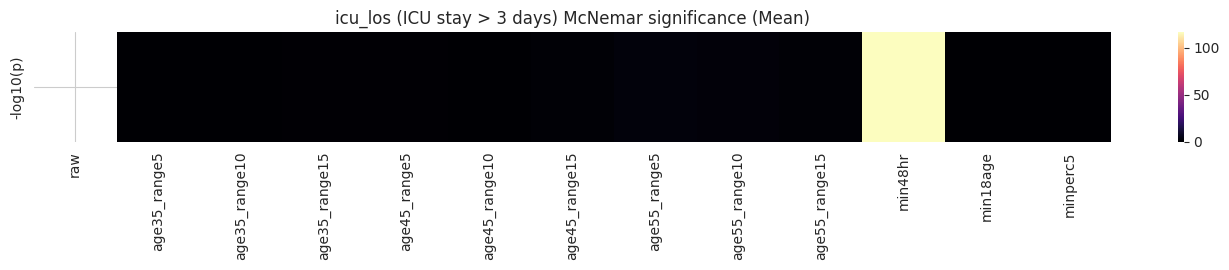

Evaluating variant=age35_range5 target=mortality method=mean


Evaluating variant=age35_range10 target=mortality method=mean


Evaluating variant=age35_range15 target=mortality method=mean


Evaluating variant=age45_range5 target=mortality method=mean
Evaluating variant=age45_range10 target=mortality method=mean


Evaluating variant=age45_range15 target=mortality method=mean


...

Evaluating variant=min48hr target=mortality method=mean


Evaluating variant=min18age target=mortality method=mean


Evaluating variant=minperc5 target=mortality method=mean


mort_hosp / hospital_expire_flag (hospital mortality) - McNemar (pooled across seeds), Mean aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train F1,Avg Test F1,Baseline Acc (var test),Baseline F1 (var test),"McNemar (Stat, p, n01, n10)"
0,raw,0.918437,0.918637,0.320910,0.325974,NaN,NaN,baseline reference
1,age35_range5,0.972839,0.968420,0.528852,0.282197,0.966651,0.330357,"0.0 (p=1.000e+00, n01=4, n10=3)"
2,age35_range10,0.964126,0.960957,0.363077,0.350138,0.959190,0.385591,"0.2 (p=6.291e-01, n01=10, n10=7)"
3,age35_range15,0.964391,0.960406,0.361454,0.326042,0.956231,0.333058,"2.2 (p=1.360e-01, n01=19, n10=10)"
4,age45_range5,0.955959,0.956820,0.424239,0.456101,0.955172,0.409843,"0.1 (p=7.905e-01, n01=8, n10=6)"
5,age45_range10,0.952906,0.954927,0.399486,0.405271,0.951893,0.366814,"3.4 (p=6.357e-02, n01=14, n10=5)"
6,age45_range15,0.951117,0.952953,0.378726,0.388293,0.952954,0.395539,"0.0 (p=1.000e+00, n01=12, n10=12)"
7,age55_range5,0.943333,0.943756,0.397822,0.365068,0.940986,0.336791,"0.8 (p=3.593e-01, n01=12, n10=7)"
8,age55_range10,0.942045,0.943263,0.334249,0.321341,0.945600,0.365136,"3.2 (p=7.076e-02, n01=10, n10=21)"
9,age55_range15,0.940464,0.939528,0.337222,0.322321,0.941647,0.350941,"4.7 (p=2.882e-02, n01=11, n10=25)"


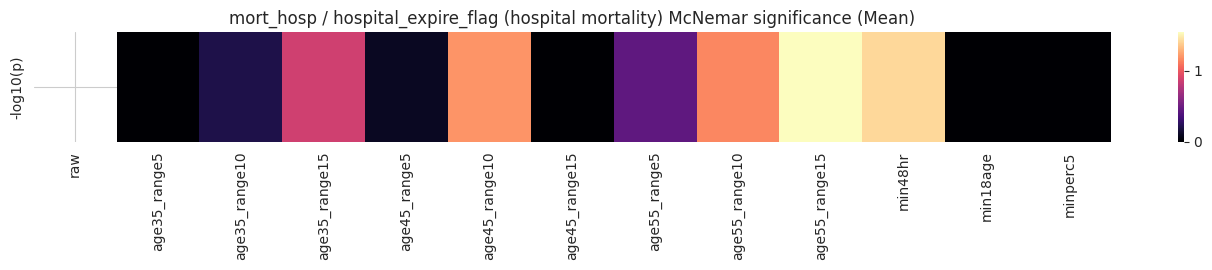

Evaluating variant=age35_range5 target=icu_los method=median


Evaluating variant=age35_range10 target=icu_los method=median


Evaluating variant=age35_range15 target=icu_los method=median


Evaluating variant=age45_range5 target=icu_los method=median
Evaluating variant=age45_range10 target=icu_los method=median


Evaluating variant=age45_range15 target=icu_los method=median


...

Evaluating variant=min48hr target=icu_los method=median


Evaluating variant=min18age target=icu_los method=median


Evaluating variant=minperc5 target=icu_los method=median


icu_los (ICU stay > 3 days) - McNemar (pooled across seeds), Median aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train F1,Avg Test F1,Baseline Acc (var test),Baseline F1 (var test),"McNemar (Stat, p, n01, n10)"
0,raw,0.699568,0.698006,0.114467,0.103701,NaN,NaN,baseline reference
1,age35_range5,0.759342,0.763510,0.307118,0.324634,0.761286,0.213708,"0.0 (p=1.000e+00, n01=22, n10=21)"
2,age35_range10,0.764554,0.768091,0.150162,0.173515,0.757075,0.147829,"4.7 (p=3.003e-02, n01=36, n10=19)"
3,age35_range15,0.762999,0.753725,0.123051,0.124582,0.753312,0.159038,"0.0 (p=1.000e+00, n01=37, n10=36)"
4,age45_range5,0.746833,0.735720,0.224747,0.152794,0.738207,0.056508,"0.1 (p=7.709e-01, n01=22, n10=25)"
5,age45_range10,0.749779,0.738383,0.171566,0.142169,0.732381,0.095044,"4.0 (p=4.437e-02, n01=45, n10=27)"
6,age45_range15,0.738449,0.731420,0.155517,0.140770,0.723432,0.085281,"12.1 (p=4.379e-04, n01=62, n10=28)"
7,age55_range5,0.720872,0.732924,0.131003,0.156185,0.732383,0.109717,"0.0 (p=1.000e+00, n01=25, n10=24)"
8,age55_range10,0.721509,0.720780,0.124065,0.108377,0.722665,0.092761,"0.9 (p=3.356e-01, n01=30, n10=39)"
9,age55_range15,0.715243,0.718963,0.126805,0.119425,0.717627,0.085006,"0.6 (p=4.307e-01, n01=56, n10=47)"


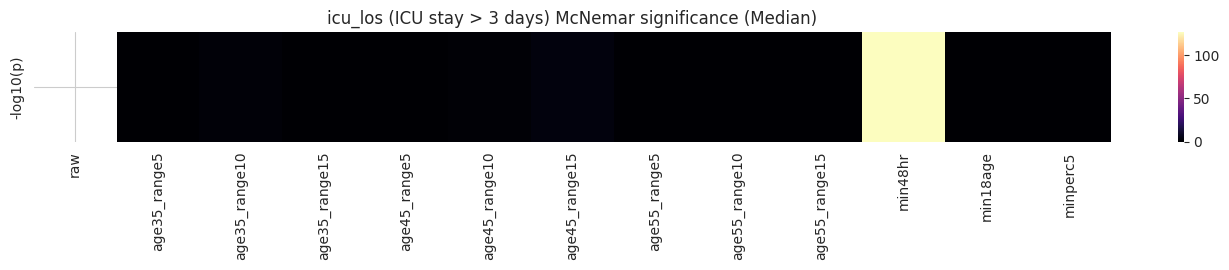

Evaluating variant=age35_range5 target=mortality method=median
Evaluating variant=age35_range10 target=mortality method=median


Evaluating variant=age35_range15 target=mortality method=median


Evaluating variant=age45_range5 target=mortality method=median
Evaluating variant=age45_range10 target=mortality method=median


Evaluating variant=age45_range15 target=mortality method=median


Evaluating variant=age55_range5 target=mortality method=median


...

Evaluating variant=min48hr target=mortality method=median


Evaluating variant=min18age target=mortality method=median


Evaluating variant=minperc5 target=mortality method=median


mort_hosp / hospital_expire_flag (hospital mortality) - McNemar (pooled across seeds), Median aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train F1,Avg Test F1,Baseline Acc (var test),Baseline F1 (var test),"McNemar (Stat, p, n01, n10)"
0,raw,0.913207,0.912944,0.229985,0.230417,NaN,NaN,baseline reference
1,age35_range5,0.971085,0.959991,0.480593,0.138889,0.972074,0.291126,"4.0 (p=3.906e-02, n01=1, n10=8)"
2,age35_range10,0.960745,0.959134,0.280860,0.311111,0.961795,0.382751,"0.4 (p=5.235e-01, n01=9, n10=13)"
3,age35_range15,0.960319,0.959969,0.251270,0.291250,0.957052,0.321333,"0.9 (p=3.449e-01, n01=17, n10=11)"
4,age45_range5,0.949634,0.951779,0.276683,0.302823,0.952660,0.297527,"0.0 (p=1.000e+00, n01=6, n10=7)"
5,age45_range10,0.948093,0.950546,0.300793,0.282367,0.947514,0.259587,"3.0 (p=7.835e-02, n01=15, n10=6)"
6,age45_range15,0.948140,0.951289,0.295944,0.294599,0.950571,0.323613,"0.2 (p=6.900e-01, n01=14, n10=11)"
7,age55_range5,0.938379,0.939851,0.280380,0.295980,0.938736,0.305388,"0.1 (p=7.905e-01, n01=8, n10=6)"
8,age55_range10,0.936906,0.939465,0.234053,0.234201,0.941788,0.305671,"3.4 (p=6.143e-02, n01=9, n10=20)"
9,age55_range15,0.935099,0.935446,0.232887,0.223393,0.936809,0.268335,"2.2 (p=1.360e-01, n01=10, n10=19)"


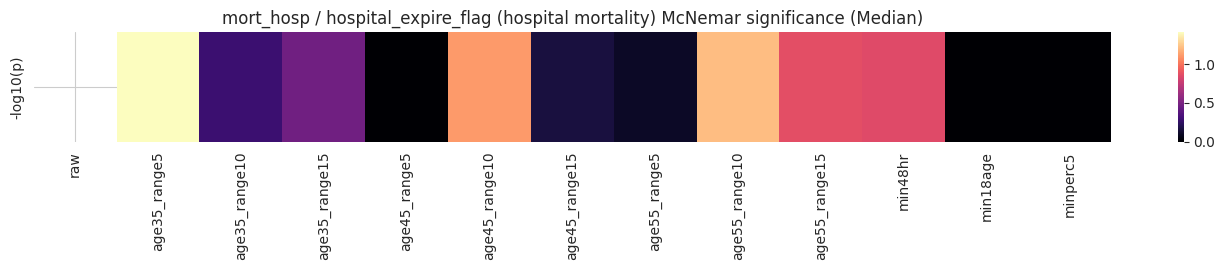

Evaluating variant=age35_range5 target=icu_los method=standard deviation
Evaluating variant=age35_range10 target=icu_los method=standard deviation


Evaluating variant=age35_range15 target=icu_los method=standard deviation
Evaluating variant=age45_range5 target=icu_los method=standard deviation


Evaluating variant=age45_range10 target=icu_los method=standard deviation


Evaluating variant=age45_range15 target=icu_los method=standard deviation


Evaluating variant=age55_range5 target=icu_los method=standard deviation


...

Evaluating variant=min48hr target=icu_los method=standard deviation


Evaluating variant=min18age target=icu_los method=standard deviation


Evaluating variant=minperc5 target=icu_los method=standard deviation


icu_los (ICU stay > 3 days) - McNemar (pooled across seeds), Standard deviation aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train F1,Avg Test F1,Baseline Acc (var test),Baseline F1 (var test),"McNemar (Stat, p, n01, n10)"
0,raw,0.734906,0.736802,0.399518,0.405254,NaN,NaN,baseline reference
1,age35_range5,0.787386,0.786756,0.445355,0.410807,0.789582,0.414982,"0.0 (p=8.506e-01, n01=13, n10=15)"
2,age35_range10,0.791267,0.782684,0.376785,0.366729,0.790313,0.415282,"1.9 (p=1.686e-01, n01=26, n10=38)"
3,age35_range15,0.784242,0.779309,0.359254,0.350823,0.779671,0.397533,"0.0 (p=1.000e+00, n01=45, n10=46)"
4,age45_range5,0.776504,0.767656,0.427772,0.405828,0.774001,0.386048,"0.7 (p=4.030e-01, n01=31, n10=39)"
5,age45_range10,0.770615,0.758471,0.377998,0.346173,0.761718,0.357262,"0.8 (p=3.866e-01, n01=49, n10=59)"
6,age45_range15,0.764440,0.761528,0.390503,0.388695,0.759375,0.376719,"0.5 (p=4.847e-01, n01=70, n10=61)"
7,age55_range5,0.753977,0.764741,0.427358,0.460326,0.763170,0.412353,"0.0 (p=8.243e-01, n01=42, n10=39)"
8,age55_range10,0.753458,0.761067,0.409058,0.437024,0.757939,0.402023,"1.1 (p=2.899e-01, n01=95, n10=80)"
9,age55_range15,0.750602,0.759653,0.415795,0.431054,0.755306,0.390190,"3.5 (p=5.939e-02, n01=125, n10=96)"


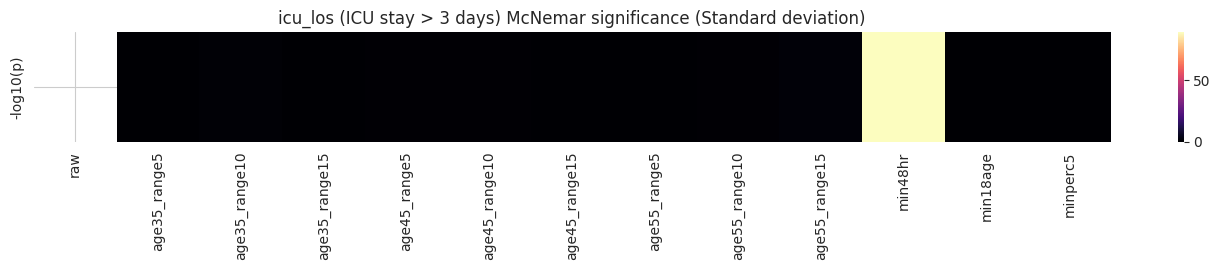

Evaluating variant=age35_range5 target=mortality method=standard deviation
Evaluating variant=age35_range10 target=mortality method=standard deviation


Evaluating variant=age35_range15 target=mortality method=standard deviation


Evaluating variant=age45_range5 target=mortality method=standard deviation


Evaluating variant=age45_range10 target=mortality method=standard deviation


Evaluating variant=age45_range15 target=mortality method=standard deviation


...

Evaluating variant=min48hr target=mortality method=standard deviation


Evaluating variant=min18age target=mortality method=standard deviation


Evaluating variant=minperc5 target=mortality method=standard deviation


mort_hosp / hospital_expire_flag (hospital mortality) - McNemar (pooled across seeds), Standard deviation aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train F1,Avg Test F1,Baseline Acc (var test),Baseline F1 (var test),"McNemar (Stat, p, n01, n10)"
0,raw,0.926560,0.925635,0.448114,0.439726,NaN,NaN,baseline reference
1,age35_range5,0.968900,0.967230,0.440532,0.288690,0.965053,0.287338,"0.0 (p=1.000e+00, n01=4, n10=3)"
2,age35_range10,0.966337,0.964628,0.442500,0.412393,0.961750,0.402632,"0.9 (p=3.438e-01, n01=7, n10=3)"
3,age35_range15,0.963465,0.962838,0.371333,0.397940,0.962743,0.447362,"0.1 (p=1.000e+00, n01=10, n10=10)"
4,age45_range5,0.961436,0.961801,0.516686,0.515221,0.962605,0.540239,"0.0 (p=1.000e+00, n01=4, n10=5)"
5,age45_range10,0.953421,0.954245,0.425044,0.415308,0.960303,0.510101,"13.1 (p=1.211e-04, n01=2, n10=20)"
6,age45_range15,0.952943,0.954850,0.436021,0.427619,0.957456,0.482673,"2.9 (p=8.953e-02, n01=12, n10=23)"
7,age55_range5,0.945076,0.931414,0.437981,0.258489,0.930241,0.300251,"0.0 (p=8.450e-01, n01=14, n10=12)"
8,age55_range10,0.946659,0.941353,0.441841,0.357632,0.940716,0.380147,"0.1 (p=7.359e-01, n01=19, n10=16)"
9,age55_range15,0.943185,0.936816,0.417074,0.350147,0.939094,0.389608,"5.6 (p=1.667e-02, n01=10, n10=25)"


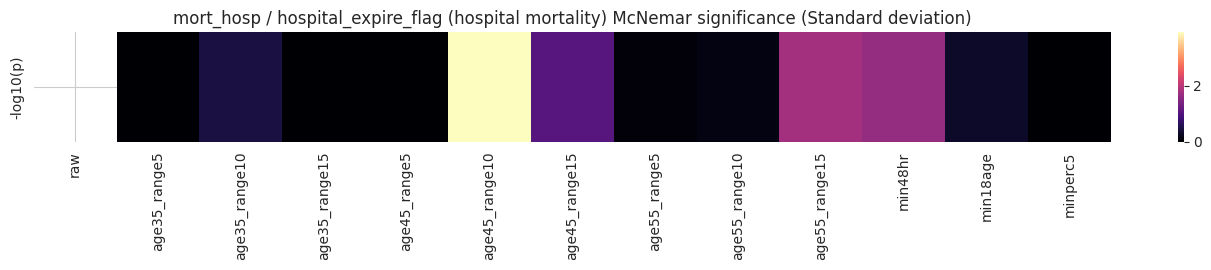

Evaluating variant=age35_range5 target=icu_los method=mean deviation


Evaluating variant=age35_range10 target=icu_los method=mean deviation


Evaluating variant=age35_range15 target=icu_los method=mean deviation


Evaluating variant=age45_range5 target=icu_los method=mean deviation


Evaluating variant=age45_range10 target=icu_los method=mean deviation


...

Evaluating variant=min48hr target=icu_los method=mean deviation


Evaluating variant=min18age target=icu_los method=mean deviation


Evaluating variant=minperc5 target=icu_los method=mean deviation


icu_los (ICU stay > 3 days) - McNemar (pooled across seeds), Mean deviation aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train F1,Avg Test F1,Baseline Acc (var test),Baseline F1 (var test),"McNemar (Stat, p, n01, n10)"
0,raw,0.766644,0.766751,0.520318,0.522780,NaN,NaN,baseline reference
1,age35_range5,0.822064,0.816708,0.573283,0.533959,0.821295,0.552729,"0.1 (p=7.011e-01, n01=12, n10=15)"
2,age35_range10,0.806966,0.817532,0.480100,0.518383,0.812740,0.535681,"0.4 (p=5.104e-01, n01=45, n10=38)"
3,age35_range15,0.800424,0.804563,0.457611,0.490233,0.803541,0.520709,"0.0 (p=9.248e-01, n01=57, n10=55)"
4,age45_range5,0.804469,0.802814,0.534885,0.517745,0.803813,0.536333,"0.0 (p=1.000e+00, n01=21, n10=22)"
5,age45_range10,0.789284,0.784497,0.469864,0.469439,0.787556,0.498199,"0.6 (p=4.394e-01, n01=49, n10=58)"
6,age45_range15,0.784632,0.788758,0.479630,0.499921,0.790162,0.520301,"0.2 (p=6.771e-01, n01=69, n10=75)"
7,age55_range5,0.782855,0.783505,0.523652,0.534126,0.782544,0.518555,"0.0 (p=8.974e-01, n01=31, n10=29)"
8,age55_range10,0.780776,0.784854,0.509421,0.525204,0.785271,0.522909,"0.0 (p=9.273e-01, n01=59, n10=61)"
9,age55_range15,0.778112,0.781836,0.521259,0.523670,0.780333,0.508522,"0.4 (p=5.117e-01, n01=99, n10=89)"


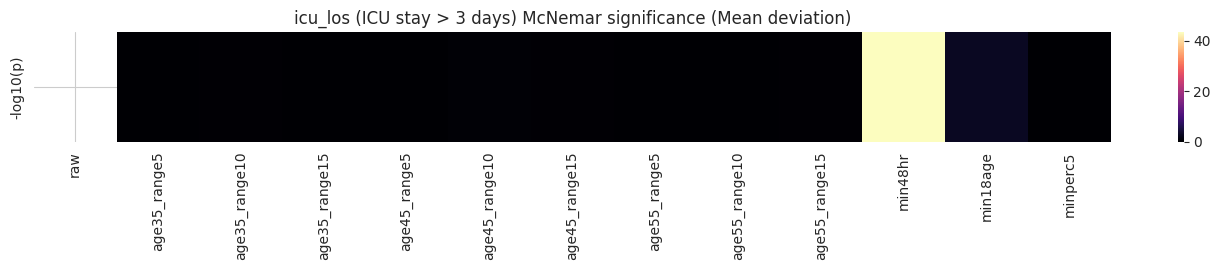

Evaluating variant=age35_range5 target=mortality method=mean deviation


Evaluating variant=age35_range10 target=mortality method=mean deviation


Evaluating variant=age35_range15 target=mortality method=mean deviation


Evaluating variant=age45_range5 target=mortality method=mean deviation


Evaluating variant=age45_range10 target=mortality method=mean deviation


...

Evaluating variant=min48hr target=mortality method=mean deviation


Evaluating variant=min18age target=mortality method=mean deviation


Evaluating variant=minperc5 target=mortality method=mean deviation


mort_hosp / hospital_expire_flag (hospital mortality) - McNemar (pooled across seeds), Mean deviation aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train F1,Avg Test F1,Baseline Acc (var test),Baseline F1 (var test),"McNemar (Stat, p, n01, n10)"
0,raw,0.925064,0.924764,0.413245,0.410932,NaN,NaN,baseline reference
1,age35_range5,0.967139,0.970464,0.397454,0.254762,0.963267,0.233766,"2.2 (p=1.250e-01, n01=4, n10=0)"
2,age35_range10,0.964639,0.961829,0.389040,0.356145,0.962537,0.385819,"0.0 (p=1.000e+00, n01=4, n10=5)"
3,age35_range15,0.964045,0.962749,0.364730,0.380893,0.964225,0.441108,"0.4 (p=5.488e-01, n01=4, n10=7)"
4,age45_range5,0.959959,0.958437,0.489974,0.447159,0.959310,0.469557,"0.0 (p=1.000e+00, n01=5, n10=6)"
5,age45_range10,0.953335,0.954585,0.416754,0.401098,0.957949,0.449895,"5.8 (p=1.294e-02, n01=2, n10=12)"
6,age45_range15,0.952760,0.953188,0.418533,0.385595,0.956040,0.425014,"6.7 (p=7.538e-03, n01=3, n10=15)"
7,age55_range5,0.945075,0.937054,0.420876,0.295156,0.934763,0.299082,"0.4 (p=5.413e-01, n01=14, n10=10)"
8,age55_range10,0.944928,0.941363,0.403910,0.318497,0.941350,0.353209,"0.0 (p=1.000e+00, n01=20, n10=20)"
9,age55_range15,0.943561,0.938619,0.405640,0.338937,0.940285,0.374333,"2.9 (p=8.953e-02, n01=12, n10=23)"


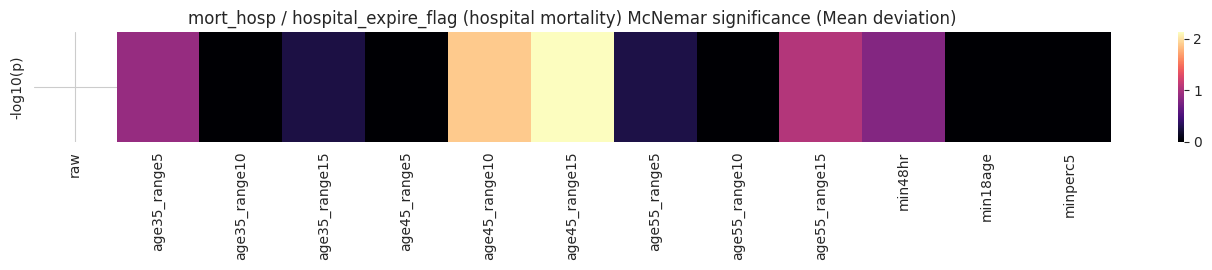

Evaluating variant=age35_range5 target=icu_los method=maximum deviation


Evaluating variant=age35_range10 target=icu_los method=maximum deviation


Evaluating variant=age35_range15 target=icu_los method=maximum deviation


Evaluating variant=age45_range5 target=icu_los method=maximum deviation


Evaluating variant=age45_range10 target=icu_los method=maximum deviation


...

Evaluating variant=min48hr target=icu_los method=maximum deviation


Evaluating variant=min18age target=icu_los method=maximum deviation


Evaluating variant=minperc5 target=icu_los method=maximum deviation


icu_los (ICU stay > 3 days) - McNemar (pooled across seeds), Maximum deviation aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train F1,Avg Test F1,Baseline Acc (var test),Baseline F1 (var test),"McNemar (Stat, p, n01, n10)"
0,raw,0.815770,0.816896,0.649257,0.652488,NaN,NaN,baseline reference
1,age35_range5,0.845173,0.854525,0.652288,0.670044,0.847577,0.647157,"0.3 (p=5.847e-01, n01=17, n10=13)"
2,age35_range10,0.847488,0.846995,0.621780,0.626944,0.849576,0.631359,"0.2 (p=6.718e-01, n01=23, n10=27)"
3,age35_range15,0.844799,0.843016,0.616108,0.631194,0.842165,0.625661,"0.0 (p=9.111e-01, n01=41, n10=39)"
4,age45_range5,0.849861,0.847692,0.674724,0.659625,0.832834,0.611659,"3.8 (p=5.045e-02, n01=47, n10=29)"
5,age45_range10,0.832073,0.821513,0.613501,0.588777,0.825485,0.600339,"1.1 (p=2.942e-01, n01=49, n10=61)"
6,age45_range15,0.822453,0.825905,0.608511,0.621503,0.824455,0.613672,"0.2 (p=6.871e-01, n01=80, n10=74)"
7,age55_range5,0.828938,0.836334,0.650439,0.661129,0.833055,0.649449,"0.4 (p=5.323e-01, n01=35, n10=29)"
8,age55_range10,0.818515,0.828052,0.624385,0.643106,0.823466,0.628135,"3.1 (p=7.555e-02, n01=81, n10=59)"
9,age55_range15,0.817002,0.825812,0.631641,0.642573,0.822084,0.625806,"3.3 (p=6.934e-02, n01=100, n10=75)"


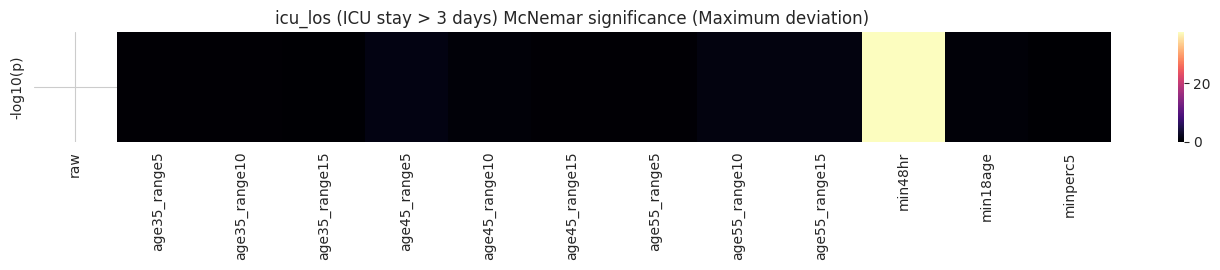

Evaluating variant=age35_range5 target=mortality method=maximum deviation


Evaluating variant=age35_range10 target=mortality method=maximum deviation


Evaluating variant=age35_range15 target=mortality method=maximum deviation


Evaluating variant=age45_range5 target=mortality method=maximum deviation


Evaluating variant=age45_range10 target=mortality method=maximum deviation


...

Evaluating variant=min48hr target=mortality method=maximum deviation


Evaluating variant=min18age target=mortality method=maximum deviation


Evaluating variant=minperc5 target=mortality method=maximum deviation


mort_hosp / hospital_expire_flag (hospital mortality) - McNemar (pooled across seeds), Maximum deviation aggregation


,Filter Name,Avg Train Acc,Avg Test Acc,Avg Train F1,Avg Test F1,Baseline Acc (var test),Baseline F1 (var test),"McNemar (Stat, p, n01, n10)"
0,raw,0.921393,0.920812,0.406435,0.383598,NaN,NaN,baseline reference
1,age35_range5,0.968007,0.963550,0.473432,0.229167,0.972237,0.375000,"1.5 (p=2.266e-01, n01=3, n10=8)"
2,age35_range10,0.963632,0.960576,0.422660,0.272894,0.962022,0.362527,"0.1 (p=7.905e-01, n01=6, n10=8)"
3,age35_range15,0.961611,0.961067,0.369831,0.355507,0.958130,0.319447,"0.7 (p=4.050e-01, n01=21, n10=15)"
4,age45_range5,0.962913,0.956000,0.535375,0.449497,0.955166,0.388820,"0.0 (p=1.000e+00, n01=9, n10=8)"
5,age45_range10,0.955054,0.953577,0.471101,0.397494,0.956604,0.452152,"2.4 (p=1.221e-01, n01=9, n10=18)"
6,age45_range15,0.953978,0.955588,0.472480,0.423776,0.954169,0.419230,"0.7 (p=4.177e-01, n01=22, n10=16)"
7,age55_range5,0.945879,0.931373,0.446457,0.293518,0.936443,0.335704,"3.4 (p=6.357e-02, n01=5, n10=14)"
8,age55_range10,0.943095,0.942226,0.407948,0.361844,0.942223,0.377978,"0.0 (p=1.000e+00, n01=15, n10=15)"
9,age55_range15,0.942202,0.939696,0.415165,0.368458,0.940003,0.395895,"0.0 (p=8.679e-01, n01=17, n10=19)"


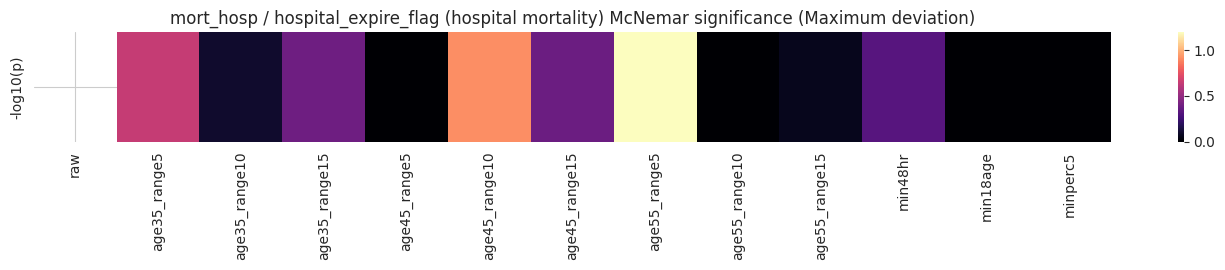

In [8]:
LABEL_DISPLAY = {
    'icu_los':   'icu_los (ICU stay > 3 days)',
    'mortality': 'mort_hosp / hospital_expire_flag (hospital mortality)',
}


def mcnemar_counts(y_true, pred_a, pred_b):
    """Discordant cells of McNemar's classifier-comparison test.

    n01 = examples where classifier A is wrong AND B is correct.
    n10 = examples where classifier A is correct AND B is wrong.
    Concordant cells (both right or both wrong) are not informative under
    McNemar and are not returned.
    """
    y = np.asarray(y_true).astype(int)
    a_correct = np.asarray(pred_a).astype(int) == y
    b_correct = np.asarray(pred_b).astype(int) == y
    n01 = int(np.sum(~a_correct &  b_correct))
    n10 = int(np.sum( a_correct & ~b_correct))
    return n01, n10


def mcnemar_pooled(n01_total, n10_total):
    """Pool discordant counts across folds and return (stat, p).

    Uses the continuity-corrected statistic and an exact two-sided binomial
    p-value over the n01+n10 discordant pairs, which avoids the Type-I
    inflation of taking min-p across seeds.
    """
    n = n01_total + n10_total
    if n == 0:
        return 0.0, 1.0
    stat = (abs(n01_total - n10_total) - 1.0) ** 2 / n
    try:
        from scipy.stats import binom
        p_one = binom.cdf(min(n01_total, n10_total), n, 0.5)
        p = float(min(1.0, 2.0 * p_one))
    except Exception:
        p = float('nan')
    return float(stat), p


def impute_and_scale(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    col_means = X.mean(axis=0, skipna=True).fillna(0.0)
    X = X.fillna(col_means).fillna(0.0)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.values)
    return Xs, scaler, col_means


def _ensure_multiindex(arr, names):
    """train_test_split on a MultiIndex returns an object array of tuples on
    some pandas versions, which then no longer round-trips through
    `.intersection`. Force back to MultiIndex with the original level names.
    """
    if isinstance(arr, pd.MultiIndex):
        return arr
    return pd.MultiIndex.from_tuples([tuple(t) for t in arr], names=names)


def evaluate_for_method(method, target_label, max_variants=None):
    base_pat = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
    y_base = _select_pos_label(base_pat, target_label)

    X_base_full = BASELINE['X']
    X_base_small = subset_X_by_patients(X_base_full, base_pat)
    X_base_agg = build_record_aggregated_features(X_base_small, method).loc[base_pat.index]
    base_cols = X_base_agg.columns

    raw_metrics = {'train_acc': [], 'test_acc': [], 'train_f1': [], 'test_f1': []}
    raw_preds_by_seed = {}
    raw_models_by_seed = {}

    idx = X_base_agg.index
    for seed in SEEDS:
        train_ids, test_ids = train_test_split(
            idx,
            test_size=TEST_SIZE,
            random_state=seed,
            stratify=y_base.loc[idx].values,
        )
        train_ids = _ensure_multiindex(train_ids, idx.names)
        test_ids  = _ensure_multiindex(test_ids,  idx.names)
        assert test_ids.intersection(idx).size == len(test_ids), \
            'MultiIndex round-trip lost rows'

        X_tr = X_base_agg.loc[train_ids]
        X_te = X_base_agg.loc[test_ids]
        y_tr = y_base.loc[train_ids].values
        y_te = y_base.loc[test_ids].values

        if len(np.unique(y_tr)) < 2:
            continue

        X_trs, scaler, col_means = impute_and_scale(X_tr)
        X_te_filled = (X_te.replace([np.inf, -np.inf], np.nan)
                          .fillna(col_means).fillna(0.0))
        X_tes = scaler.transform(X_te_filled.values)

        clf = LogisticRegression(**MODEL_KWARGS)
        clf.fit(X_trs, y_tr)
        pred_tr = clf.predict(X_trs)
        pred_te = clf.predict(X_tes)

        raw_metrics['train_acc'].append(accuracy_score(y_tr, pred_tr))
        raw_metrics['test_acc'].append(accuracy_score(y_te, pred_te))
        raw_metrics['train_f1'].append(f1_score(y_tr, pred_tr, zero_division=0))
        raw_metrics['test_f1'].append(f1_score(y_te, pred_te, zero_division=0))

        raw_preds_by_seed[seed]  = (test_ids, pred_te, y_te)
        raw_models_by_seed[seed] = (clf, scaler, col_means, base_cols)

    results = {
        'raw': {
            'train_acc': float(np.mean(raw_metrics['train_acc'])),
            'test_acc':  float(np.mean(raw_metrics['test_acc'])),
            'train_f1':  float(np.mean(raw_metrics['train_f1'])),
            'test_f1':   float(np.mean(raw_metrics['test_f1'])),
            'baseline_acc_on_var_test': np.nan,
            'baseline_f1_on_var_test':  np.nan,
            'mcnemar': None,
        }
    }

    variants = VARIANT_OBJS if max_variants is None else VARIANT_OBJS[:max_variants]
    for v in variants:
        print(f'Evaluating variant={v["name"]} target={target_label} method={method}')
        v_pat = maybe_sample_record_ids(v['patients'], MAX_RECORDS_PER_SCENARIO)
        y_v = _select_pos_label(v_pat, target_label)

        X_v_full = v.get('X', None)
        if X_v_full is None:
            X_v_full = pd.read_hdf(str(v['datafile']), 'vitals_labs')
        X_v_small = subset_X_by_patients(X_v_full, v_pat)
        X_v_agg = build_record_aggregated_features(X_v_small, method).loc[v_pat.index]

        metrics = {'train_acc': [], 'test_acc': [], 'train_f1': [], 'test_f1': []}
        base_metrics_intersection = {'acc': [], 'f1': []}
        n01_total = 0
        n10_total = 0

        for seed in SEEDS:
            base_test_ids, _, _ = raw_preds_by_seed[seed]
            test_ids_v = v_pat.index.intersection(base_test_ids)
            if len(test_ids_v) < 10:
                continue
            train_ids_v = v_pat.index.difference(test_ids_v)
            if len(train_ids_v) < 10:
                continue

            X_tr = X_v_agg.loc[train_ids_v]
            X_te = X_v_agg.loc[test_ids_v]
            y_tr = y_v.loc[train_ids_v].values
            y_te = y_v.loc[test_ids_v].values

            if len(np.unique(y_tr)) < 2:
                continue

            X_trs, scaler, col_means = impute_and_scale(X_tr)
            X_te_filled = (X_te.replace([np.inf, -np.inf], np.nan)
                              .fillna(col_means).fillna(0.0))
            X_tes = scaler.transform(X_te_filled.values)

            clf = LogisticRegression(**MODEL_KWARGS)
            clf.fit(X_trs, y_tr)
            pred_tr = clf.predict(X_trs)
            pred_te_var = clf.predict(X_tes)

            metrics['train_acc'].append(accuracy_score(y_tr, pred_tr))
            metrics['test_acc'].append(accuracy_score(y_te, pred_te_var))
            metrics['train_f1'].append(f1_score(y_tr, pred_tr, zero_division=0))
            metrics['test_f1'].append(f1_score(y_te, pred_te_var, zero_division=0))

            # Replay the baseline classifier on the *same* test patients,
            # using baseline's feature schema and scaler. test_ids_v is
            # guaranteed a subset of X_base_agg.index because it was sliced
            # out of the baseline split.
            base_clf, base_scaler, base_col_means, base_schema_cols = raw_models_by_seed[seed]
            X_te_base = X_base_agg.loc[test_ids_v, base_schema_cols]
            X_te_base = (X_te_base.replace([np.inf, -np.inf], np.nan)
                                  .fillna(base_col_means).fillna(0.0))
            base_pred_on_v = base_clf.predict(base_scaler.transform(X_te_base.values))

            base_metrics_intersection['acc'].append(accuracy_score(y_te, base_pred_on_v))
            base_metrics_intersection['f1'].append(f1_score(y_te, base_pred_on_v, zero_division=0))

            n01, n10 = mcnemar_counts(y_te, base_pred_on_v, pred_te_var)
            n01_total += n01
            n10_total += n10

        if metrics['test_acc']:
            stat_pool, p_pool = mcnemar_pooled(n01_total, n10_total)
            mcnemar_entry = (stat_pool, p_pool, n01_total, n10_total)
        else:
            mcnemar_entry = (np.nan, np.nan, 0, 0)

        results[v['name']] = {
            'train_acc': float(np.mean(metrics['train_acc'])) if metrics['train_acc'] else np.nan,
            'test_acc':  float(np.mean(metrics['test_acc']))  if metrics['test_acc']  else np.nan,
            'train_f1':  float(np.mean(metrics['train_f1']))  if metrics['train_f1']  else np.nan,
            'test_f1':   float(np.mean(metrics['test_f1']))   if metrics['test_f1']   else np.nan,
            'baseline_acc_on_var_test': (
                float(np.mean(base_metrics_intersection['acc']))
                if base_metrics_intersection['acc'] else np.nan
            ),
            'baseline_f1_on_var_test': (
                float(np.mean(base_metrics_intersection['f1']))
                if base_metrics_intersection['f1'] else np.nan
            ),
            'mcnemar': mcnemar_entry,
        }

        try:
            del X_v_full, X_v_small, X_v_agg
        except Exception:
            pass

    return results


def show_results(results_dict, target_label, method):
    names = ['raw'] + [n for n in results_dict.keys() if n != 'raw']
    rows = []
    for name in names:
        r = results_dict[name]
        if name == 'raw' or r['mcnemar'] is None:
            m_str = 'baseline reference'
        else:
            stat, p, n01, n10 = r['mcnemar']
            m_str = f'{stat:.1f} (p={p:.3e}, n01={n01}, n10={n10})'
        rows.append([
            name,
            r['train_acc'], r['test_acc'],
            r['train_f1'],  r['test_f1'],
            r.get('baseline_acc_on_var_test', np.nan),
            r.get('baseline_f1_on_var_test',  np.nan),
            m_str,
        ])
    df = pd.DataFrame(rows, columns=[
        'Filter Name', 'Avg Train Acc', 'Avg Test Acc',
        'Avg Train F1', 'Avg Test F1',
        'Baseline Acc (var test)', 'Baseline F1 (var test)',
        'McNemar (Stat, p, n01, n10)',
    ])
    print(f'{LABEL_DISPLAY[target_label]} - McNemar (pooled across seeds), '
          f'{method.capitalize()} aggregation')
    display(df)
    return df


def visualize_mcnemar_significance(results_dict, target_label, method):
    filter_names = ['raw'] + [n for n in results_dict.keys() if n != 'raw']
    pvals = []
    for n in filter_names:
        if n == 'raw' or results_dict[n]['mcnemar'] is None:
            pvals.append(np.nan)
            continue
        _, p, _, _ = results_dict[n]['mcnemar']
        pvals.append(p)
    vals = []
    for p in pvals:
        try:
            fp = float(p)
            vals.append(-np.log10(max(fp, 1e-300)) if fp == fp else np.nan)
        except Exception:
            vals.append(np.nan)
    df = pd.DataFrame([vals], columns=filter_names, index=['-log10(p)'])
    plt.figure(figsize=(14, 2.8))
    sns.heatmap(df, cmap='magma')
    plt.title(f'{LABEL_DISPLAY[target_label]} McNemar significance ({method.capitalize()})')
    plt.tight_layout()
    plt.show()


# Run the full sweep across all five aggregation methods.
for method in AGG_METHODS:
    for target_label in LABELS:
        res = evaluate_for_method(method, target_label)
        show_results(res, target_label=target_label, method=method)
        visualize_mcnemar_significance(res, target_label=target_label, method=method)


# Centroid shift 

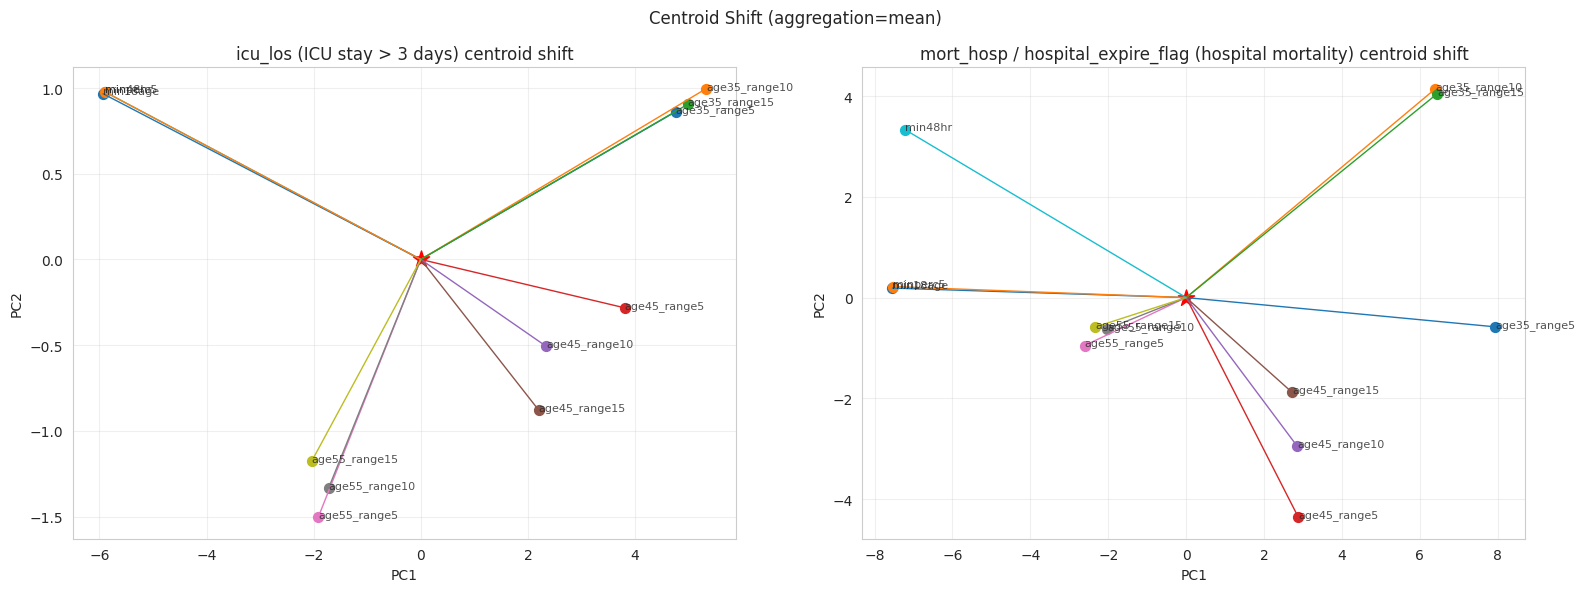

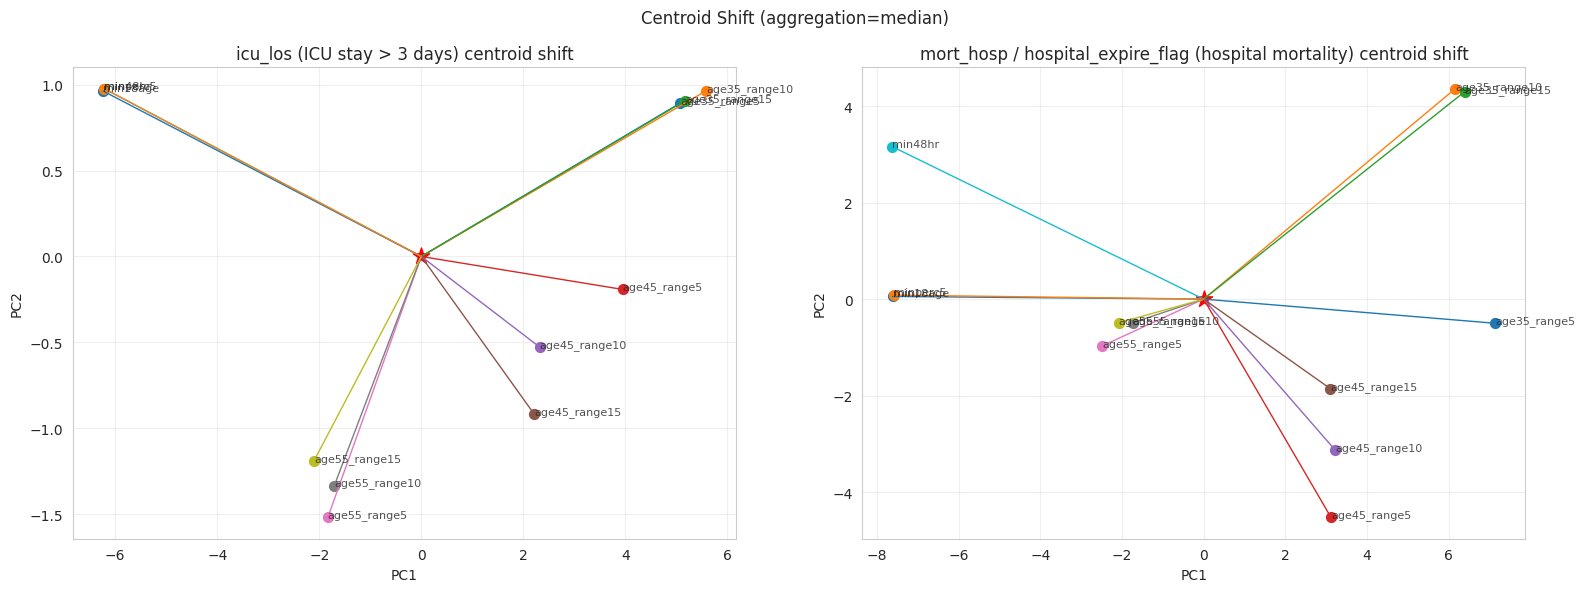

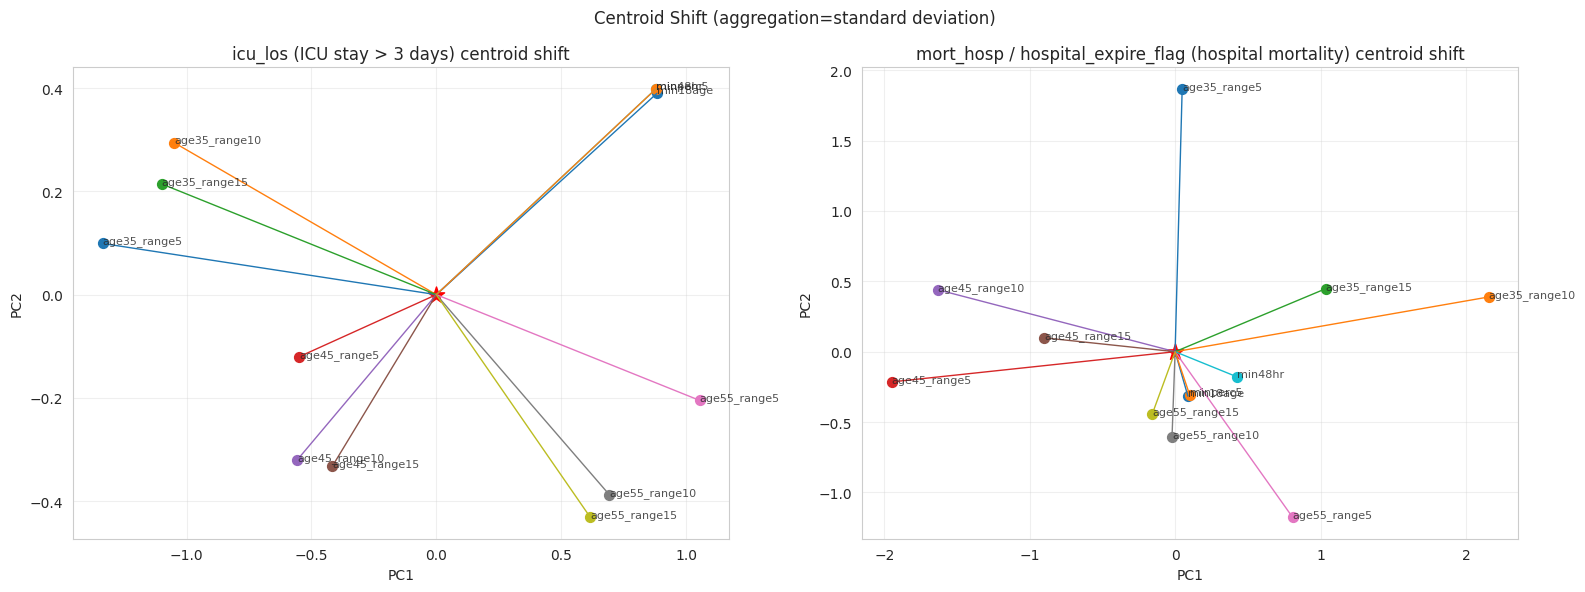

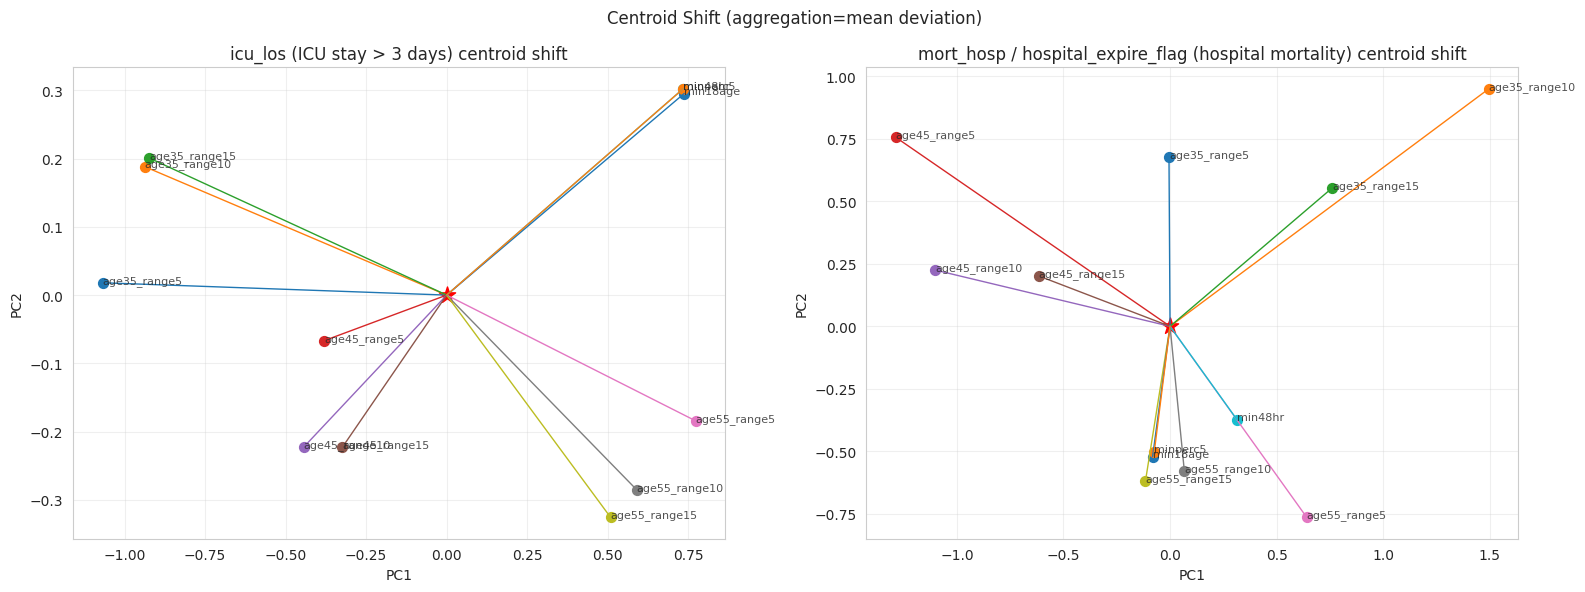

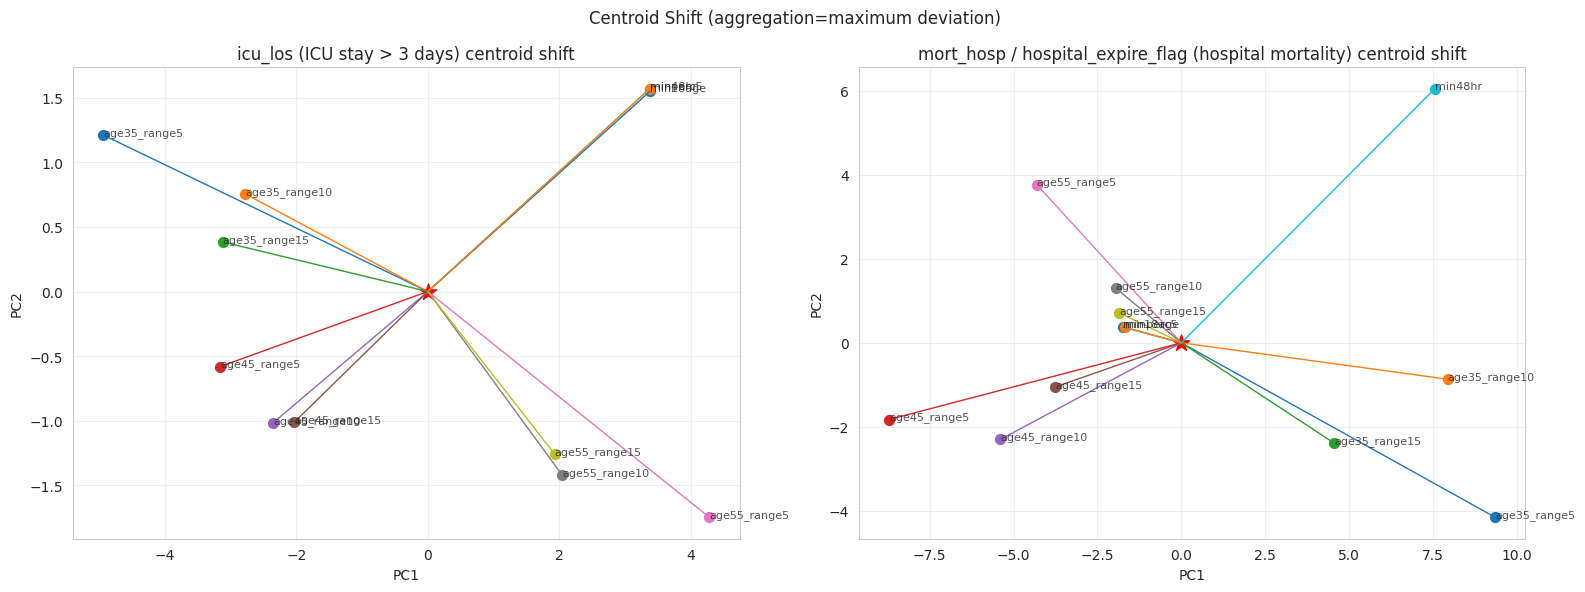

In [9]:
def compute_centroid(X_agg, patients_df, target_label):
    """Mean feature vector across positive-class records, with per-column
    mean imputation for any remaining NaN cells (no zero fill)."""
    y = _select_pos_label(patients_df, target_label)
    y = y.loc[X_agg.index]
    sel = y.values == 1
    if sel.sum() == 0:
        return None
    block = X_agg.loc[y.index[sel]]
    col_means = block.mean(axis=0, skipna=True)
    block_filled = block.fillna(col_means)
    vec = block_filled.mean(axis=0, skipna=True).values
    # Fall back to 0 only for columns that are entirely NaN among positives;
    # other columns reflect actual data via mean imputation above.
    vec = np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)
    return vec


def visualize_centroid_shift(method):
    base_pat = maybe_sample_record_ids(BASELINE['patients'], MAX_RECORDS_PER_SCENARIO)
    X_base_full = BASELINE['X']
    X_base_small = subset_X_by_patients(X_base_full, base_pat)
    X_base_agg = build_record_aggregated_features(X_base_small, method).loc[base_pat.index]

    # Aggregate every variant once; remember which baseline columns each one
    # actually kept.
    variant_aggs = []
    for v in VARIANT_OBJS:
        pat = maybe_sample_record_ids(v['patients'], MAX_RECORDS_PER_SCENARIO)
        X_v_full = v.get('X', None)
        if X_v_full is None:
            X_v_full = pd.read_hdf(str(v['datafile']), 'vitals_labs')
        Xv_small = subset_X_by_patients(X_v_full, pat)
        Xv_agg = build_record_aggregated_features(Xv_small, method).loc[pat.index]
        variant_aggs.append({
            'name': v['name'],
            'pat':  pat,
            'X':    Xv_agg,
            'cols': Xv_agg.columns,
        })
        try:
            del X_v_full, Xv_small
        except Exception:
            pass

    # Globally-shared columns: kept by baseline AND by every variant. PCA
    # then operates on equal-length shift vectors. Phantom shifts driven by
    # missing-column zero-fills are no longer possible.
    global_shared = X_base_agg.columns
    for va in variant_aggs:
        global_shared = global_shared.intersection(va['cols'])
    Xb_global = X_base_agg[global_shared]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, lab in zip(axes, LABELS):
        cb = compute_centroid(Xb_global, base_pat, lab)
        if cb is None:
            ax.set_title(f'{LABEL_DISPLAY[lab]} (no baseline centroid)')
            ax.grid(True, alpha=0.3)
            continue

        shift_vecs = []
        names = []
        for va in variant_aggs:
            Xv_global = va['X'][global_shared]
            cv = compute_centroid(Xv_global, va['pat'], lab)
            if cv is None:
                continue
            n_dropped_vs_baseline = len(X_base_agg.columns) - len(va['cols'])
            shift_vecs.append(cv - cb)
            label = va['name']
            if n_dropped_vs_baseline:
                label += f' (-{n_dropped_vs_baseline})'
            names.append(label)

        if not shift_vecs:
            ax.set_title(f'{LABEL_DISPLAY[lab]} (no variant centroids)')
            ax.grid(True, alpha=0.3)
            continue

        if len(shift_vecs) < 2:
            ax.scatter([0], [0], marker='*', s=150, c='red')
            ax.scatter([0], [0], s=50)
            ax.annotate(names[0], (0, 0), fontsize=8, alpha=0.8)
            ax.set_title(f'{LABEL_DISPLAY[lab]} (insufficient variants for PCA)')
            ax.grid(True, alpha=0.3)
            continue

        Z = PCA(n_components=2, random_state=0).fit_transform(np.vstack(shift_vecs))
        ax.scatter([0], [0], marker='*', s=150, c='red', label='baseline')
        for i, n in enumerate(names):
            ax.scatter([Z[i, 0]], [Z[i, 1]], s=50)
            ax.annotate(n, (Z[i, 0], Z[i, 1]), fontsize=8, alpha=0.8)
            ax.plot([0, Z[i, 0]], [0, Z[i, 1]], linewidth=1)
        ax.set_title(f'{LABEL_DISPLAY[lab]} centroid shift')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Centroid Shift (aggregation={method})')
    plt.tight_layout()
    plt.show()


for method in AGG_METHODS:
    visualize_centroid_shift(method)


# Extra visuals 

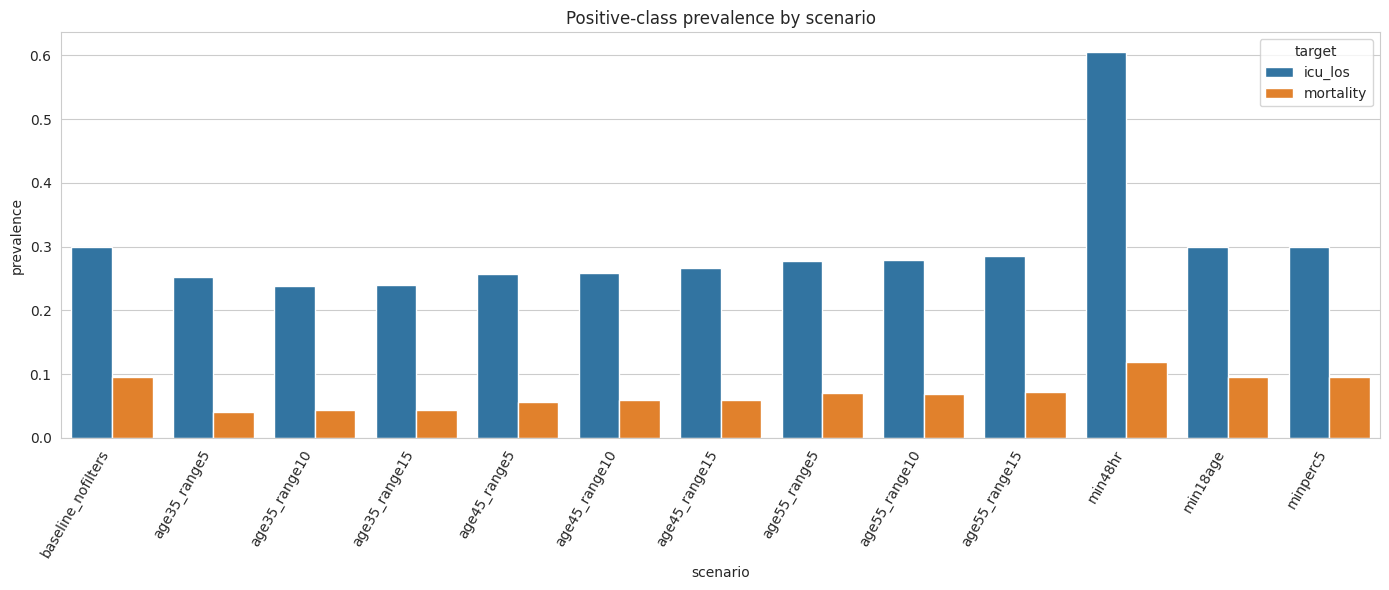

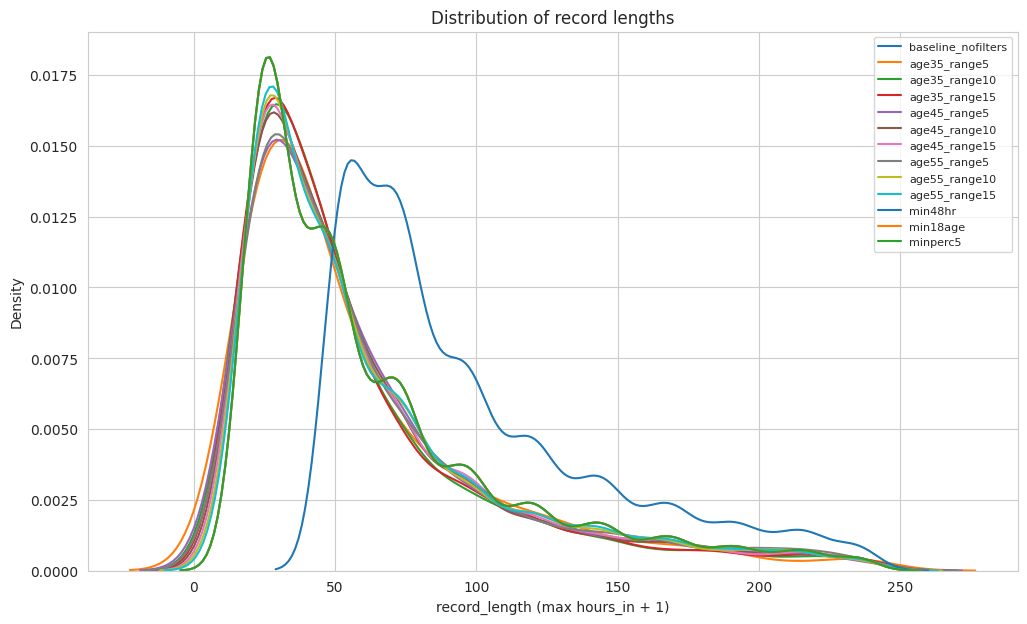

In [10]:
def fenceposts_to_record_lengths(scenario_dir, max_records=None):
    fp_path = scenario_dir / 'fenceposts.npy'
    fp = np.load(str(fp_path))
    if max_records is not None and len(fp) > max_records:
        rng = np.random.default_rng(0)
        fp = fp[rng.choice(len(fp), size=max_records, replace=False)]
    return fp + 1

rows = []
for v in [BASELINE] + VARIANT_OBJS:
    # Prevalence
    patients = v['patients']
    for lab in LABELS:
        y = _select_pos_label(patients, lab)
        rows.append({'scenario': v['name'], 'target': lab, 'prevalence': float(y.mean())})

df_prev = pd.DataFrame(rows)
plt.figure(figsize=(14, 6))
sns.barplot(data=df_prev, x='scenario', y='prevalence', hue='target')
plt.title('Positive-class prevalence by scenario')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
for v in [BASELINE] + VARIANT_OBJS:
    scenario_dir = Path(v['datafile']).parent
    lens = fenceposts_to_record_lengths(scenario_dir, max_records=MAX_RECORDS_PER_SCENARIO)
    sns.kdeplot(lens, label=v['name'], warn_singular=False)
plt.title('Distribution of record lengths')
plt.xlabel('record_length (max hours_in + 1)')
plt.legend(fontsize=8)
plt.show()
